In [0]:
gold_listings = spark.table('workspace.default.gold_listings')
gold_reviews = spark.table('workspace.default.gold_reviews')
gold_calendar = spark.table('workspace.default.gold_calendar')
gold_calendar_daily = spark.table('workspace.default.gold_calendar_daily')

In [0]:
# import necessary libraries
from pyspark.sql import functions as F
from pyspark.sql.window import Window
import matplotlib.pyplot as plt
import seaborn as sns
from pyspark.ml.feature import StringIndexer, VectorAssembler
from pyspark.ml import Pipeline
from pyspark.ml.regression import GBTRegressor
from pyspark.ml.evaluation import RegressionEvaluator

# Step 1: Pricing Distribution Analysis
Establish pricing benchmarks for each city, neighborhood, and property type, and compare weekend versus weekday price premiums.

## Step 1-A: Identify Outlier Threshold (IQR Method)

In [0]:
# --- Step 1-A: Calculate specific IQR bounds for each city ---

# 1. Group by city to find the 25th (Q1) and 75th (Q3) percentiles
# Using approxQuantile is not possible with GroupBy, so we use percentile_approx instead
city_stats = gold_listings.groupBy('city').agg(
    F.percentile_approx('price', 0.25).alias('q1'),
    F.percentile_approx('price', 0.75).alias('q3')
)

# 2. Calculate IQR and define the Upper Bound (Q3 + 1.5 * IQR)
# This formula effectively identifies extreme values like the $50,000 listing in Seattle
city_stats = city_stats.withColumn('iqr', F.col('q3') - F.col('q1')) \
                       .withColumn('city_upper_bound', F.col('q3') + 1.5 * F.col('iqr'))

# 3. Join the city-specific thresholds back to the main dataset
gold_listings_with_bounds = gold_listings.join(
    city_stats.select('city', 'city_upper_bound'), 
    on='city', 
    how='left'
)

print("City-specific outlier thresholds have been established.")
display(city_stats.select('city', 'city_upper_bound'))

City-specific outlier thresholds have been established.


city,city_upper_bound
austin,436.0
nashville,426.5
chicago,454.5
seattle,372.5
twin_cities,415.0


## Step 1-B: Data Cleaning & Verification

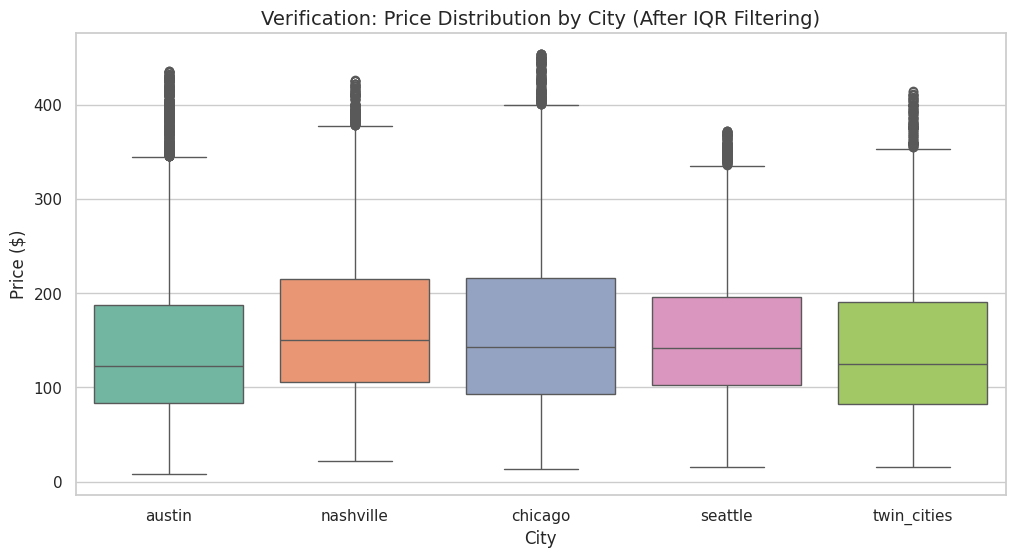

Total records remaining after city-specific cleaning: 33065


In [0]:
# --- Step 1-B: Filter outliers and verify with a visualization ---

# 1. Create the clean dataset by removing listings above their city's upper bound
clean_listings = gold_listings_with_bounds.filter(F.col('price') <= F.col('city_upper_bound'))

# 2. Visual Verification: Plotting the cleaned price distribution
# Convert to Pandas for visualization (safe to do after outlier removal)
pdf_clean = clean_listings.select('city', 'price').toPandas()

plt.figure(figsize=(12, 6))
sns.set(style="whitegrid")

# Create a Box Plot to check each cities' pricing bundaries
sns.boxplot(x='city', y='price', hue='city', data=pdf_clean, palette='Set2', legend=False)

plt.title('Verification: Price Distribution by City (After IQR Filtering)', fontsize=14)
plt.ylabel('Price ($)')
plt.xlabel('City')
plt.show()

print(f"Total records remaining after city-specific cleaning: {clean_listings.count()}")

# Step 2: Occupancy modeling
Use gold_calendar to estimate the actual demand intensity for each property listing and identify peak and off-peak seasons.

## Step 2-A: Occupancy Rate Calculation and Rolling Window Analysis

In [0]:

# --- Step 2-A-1: Individual Listing Occupancy (Total) ---
# We calculate the overall occupancy for verification against Phase 1's availability_rate.
# In 'is_available', 0 means booked/not available, 1 means available.
occupancy_raw = gold_calendar_daily.groupBy('listing_id').agg(
    F.count('*').alias('total_days'),
    F.sum(F.when(F.col('is_available') == 0, 1).otherwise(0)).alias('booked_days')
)

occupancy_raw = occupancy_raw.withColumn(
    'occupancy_rate',
    (F.col('booked_days') / F.col('total_days')).cast('double')
)

# --- Step 2-A-2: 90-Day Rolling Occupancy Window ---
# This identifies mid-term demand trends for the AI Agent.
# Note: Using 'calendar_date' and 'listing_id' from your new daily table.
w90 = Window.partitionBy('listing_id').orderBy('calendar_date').rowsBetween(-89, 0)

# Apply the window to calculate rolling 90-day booking counts
occ_90d_df = gold_calendar_daily \
    .withColumn('is_booked', F.when(F.col('is_available') == 0, 1).otherwise(0)) \
    .withColumn('booked_90d', F.sum(F.col('is_booked')).over(w90)) \
    .withColumn('occupancy_rate_90d', F.col('booked_90d') / 90)

# Display the results to verify the rolling calculation
display(occ_90d_df.select('listing_id', 'calendar_date', 'occupancy_rate_90d').limit(10))

listing_id,calendar_date,occupancy_rate_90d
2384,2025-09-22,0.011111111111111112
2384,2025-09-23,0.022222222222222223
2384,2025-09-24,0.022222222222222223
2384,2025-09-25,0.03333333333333333
2384,2025-09-26,0.044444444444444446
2384,2025-09-27,0.05555555555555555
2384,2025-09-28,0.06666666666666667
2384,2025-09-29,0.06666666666666667
2384,2025-09-30,0.06666666666666667
2384,2025-10-01,0.06666666666666667


## 2-B  Identifying Peak and Off-Peak Months

In [0]:
# --- 1. Aggregate occupancy by month for each neighborhood ---
# We only select 'listing_id' and 'neighbourhood_cleansed' from listings 
# because 'city' already exists in our occupancy table.
monthly_occ = occ_90d_df \
    .join(clean_listings.select('listing_id', 'neighbourhood_cleansed'), 
          on='listing_id', 
          how='inner') \
    .groupBy(
        'city',
        'neighbourhood_cleansed', 
        F.month('calendar_date').alias('month')
    ) \
    .agg(F.avg('occupancy_rate_90d').alias('avg_monthly_occ'))

# --- 2. Identify the peak month per neighborhood ---
w_peak = Window.partitionBy('city', 'neighbourhood_cleansed') \
               .orderBy(F.col('avg_monthly_occ').desc())

peak_months = monthly_occ \
    .withColumn('rank', F.rank().over(w_peak)) \
    .filter(F.col('rank') == 1) \
    .select(
        'city', 
        'neighbourhood_cleansed', 
        F.col('month').alias('peak_month'),
        F.round('avg_monthly_occ', 4).alias('peak_occupancy_rate')
    )

# --- 3. Preview the results ---
print("Neighborhood Peak Seasons identified:")
display(peak_months.limit(10))

Neighborhood Peak Seasons identified:


city,neighbourhood_cleansed,peak_month,peak_occupancy_rate
austin,78701,8,0.3655
austin,78702,8,0.4783
austin,78703,8,0.389
austin,78704,8,0.4357
austin,78705,8,0.3824
austin,78717,8,0.3289
austin,78719,8,0.7153
austin,78721,8,0.4176
austin,78722,8,0.5462
austin,78723,8,0.4976


# Step 3: Competitiveness Score
Calculate the relative competitive position of each property within its neighborhood.

| Column Name                 | Calculation Method | Weight                                    | 
|-----------------------------|----------|--------------------------------------------------|
| price_gap_pct                  | (Listing Price - Neighborhood Median Price) / Neighborhood Median Price * 100     | 30%|
| amenity_score                        | amenities_count normalzied to 0-100 (realtive to the neighborhood average)   | 25%|
| review_count_rank                | Percentile ranking within the community   | 25%|
| occupancy_rank                   | Percentile ranking within the community   | 20%| 


## 3-A price_gap_pct and neighborhood median
We calculate the percentage deviation of a listing's price relative to the median price of its specific peer group (same neighborhood and room type).

Formula: ((Price−Median)/Median)×100

Competitive Advantage: A negative percentage (e.g., -15%) indicates the listing is priced below the market median, suggesting higher value to guests.
* Optimization Signal: A high positive percentage (e.g., +25%) signals the AI Agent to investigate if the listing's luxury features justify the premium or if a price drop is necessary to boost occupancy.

In [0]:
# Define the window partitioned by neighborhood and room type to ensure 
# we are comparing "apples to apples" (e.g., entire homes vs. other entire homes in the same area).
# [cite: 172, 173, 254]
window_neighborhood = Window.partitionBy('neighbourhood_cleansed', 'room_type')

# Calculate the median neighborhood price and the resulting price gap percentage.
# We use clean_listings (after IQR filtering) to ensure the baseline is accurate. [cite: 164, 173]
listings_scored = clean_listings \
    .withColumn('median_neighborhood_price', 
                F.percentile_approx('price', 0.50).over(window_neighborhood)) \
    .withColumn('price_gap_pct', 
                ((F.col('price') - F.col('median_neighborhood_price')) / 
                 F.col('median_neighborhood_price') * 100).cast('double'))

# Select key columns for verification, including the corrected listing_id 
# and rounding the gap percentage for professional presentation. 
display(listings_scored.select(
    'listing_id', 
    'city', 
    'neighbourhood_cleansed', 
    'room_type',
    'price', 
    'median_neighborhood_price', 
    F.round('price_gap_pct', 2).alias('price_gap_pct')
).limit(10))

listing_id,city,neighbourhood_cleansed,room_type,price,median_neighborhood_price,price_gap_pct
46529406,austin,78701,entire home/apt,87.0,197.0,-55.84
583823273939691037,austin,78701,entire home/apt,108.0,197.0,-45.18
725362364628157858,austin,78701,entire home/apt,124.0,197.0,-37.06
771264203043121777,austin,78701,entire home/apt,403.0,197.0,104.57
776163115233553525,austin,78701,entire home/apt,221.0,197.0,12.18
802673809026795037,austin,78701,entire home/apt,205.0,197.0,4.06
842066613080484785,austin,78701,entire home/apt,350.0,197.0,77.66
1050075031752413309,austin,78701,entire home/apt,183.0,197.0,-7.11
1138706281079728392,austin,78701,entire home/apt,121.0,197.0,-38.58
1297902550665799343,austin,78701,entire home/apt,232.0,197.0,17.77


## Step 3-B: amenity_score Amenity Superiority Engineering
We normalize the number of amenities in a listing against the average for “the same neighborhood and the same unit type” to generate an amenity_score on a scale of 0–100.

In [0]:
# Use the same window partition (Neighborhood + Room Type) to compare amenity levels
# This ensures a "private room" isn't penalized for having fewer amenities than an "entire home".
#
window_context = Window.partitionBy('neighbourhood_cleansed', 'room_type')

# Calculate the neighborhood average and maximum for normalization.
# We then compute the amenity_score, capping it at 100.0 to prevent outliers from breaking the scale.
listings_scored = listings_scored \
    .withColumn('neigh_avg_amenities', F.avg('amenities_count').over(window_context)) \
    .withColumn('neigh_max_amenities', F.max('amenities_count').over(window_context)) \
    .withColumn('amenity_score', 
                F.least(
                    F.lit(100.0), 
                    (F.col('amenities_count') / F.col('neigh_max_amenities') * 100).cast('double')
                ))

# Round values for a professional look in the final gold_features table.
display(listings_scored.select(
    'listing_id', 
    'neighbourhood_cleansed', 
    'room_type', 
    'amenities_count', 
    F.round('neigh_avg_amenities', 1).alias('avg_in_neigh'),
    F.round('amenity_score', 2).alias('amenity_score')
).limit(10))

listing_id,neighbourhood_cleansed,room_type,amenities_count,avg_in_neigh,amenity_score
46529406,78701,entire home/apt,36,45.3,36.73
583823273939691037,78701,entire home/apt,68,45.3,69.39
725362364628157858,78701,entire home/apt,41,45.3,41.84
771264203043121777,78701,entire home/apt,63,45.3,64.29
776163115233553525,78701,entire home/apt,42,45.3,42.86
802673809026795037,78701,entire home/apt,29,45.3,29.59
842066613080484785,78701,entire home/apt,10,45.3,10.2
1050075031752413309,78701,entire home/apt,68,45.3,69.39
1138706281079728392,78701,entire home/apt,75,45.3,76.53
1297902550665799343,78701,entire home/apt,46,45.3,46.94


## 3-C review_count_rank: Relative Ranking (Trust & Market Demand)
This step calculates the Relative Rank of each listing within its specific neighborhood. By converting raw numbers into percentile ranks (0.0 to 1.0), we identify how a listing compares to its local competitors in terms of guest trust and market demand.

Business Logic for Phase 4 (AI Agent)

- Trust Building: If a listing has a low review_count_rank, the AI Agent will prioritize recommending strategies to get more reviews (e.g., automated follow-ups).

- Demand Validation: A high occupancy_rank paired with a high price_gap_pct suggests a "Premium Market Leader" that may have room to increase prices even further.

In [0]:
# 1. Define window for review count ranking
window_review = Window.partitionBy('neighbourhood_cleansed').orderBy('number_of_reviews')

# 2. Join listings_scored with the occupancy data from Step 2 first
# We ensure the primary key is 'listing_id' based on your root.docx schema.
listings_scored = listings_scored \
    .join(occ_90d_df.select('listing_id', 'occupancy_rate_90d').distinct(), 
          on='listing_id', 
          how='left')

# 3. Define window for occupancy ranking after the join (now occupancy_rate_90d exists)
window_occupancy = Window.partitionBy('neighbourhood_cleansed').orderBy('occupancy_rate_90d')

# 4. Apply the rankings
listings_scored = listings_scored \
    .withColumn('review_count_rank', F.percent_rank().over(window_review)) \
    .withColumn('occupancy_rank', F.percent_rank().over(window_occupancy))

# 5. Fill nulls for new listings to ensure score stability (0 rank for no history).
listings_scored = listings_scored.fillna({
    'review_count_rank': 0, 
    'occupancy_rank': 0, 
    'occupancy_rate_90d': 0
})

# Display for verification in your Databricks Notebook.
display(listings_scored.select(
    'listing_id', 
    'neighbourhood_cleansed', 
    'number_of_reviews', 
    F.round('review_count_rank', 3).alias('review_rank'), 
    F.round('occupancy_rate_90d', 3).alias('occ_rate_90d'),
    F.round('occupancy_rank', 3).alias('occ_rank')
).limit(10))

listing_id,neighbourhood_cleansed,number_of_reviews,review_rank,occ_rate_90d,occ_rank
736997706091137832,78701,0,0.0,0.0,0.0
1050810576575216662,78701,0,0.0,0.0,0.0
1147691461254312780,78701,0,0.0,0.0,0.0
1147692298498919319,78701,0,0.0,0.0,0.0
1284017961958369153,78701,0,0.0,0.0,0.0
1305231804628370773,78701,0,0.0,0.0,0.0
1325533956557241114,78701,0,0.0,0.0,0.0
1401465397153469181,78701,0,0.0,0.0,0.0
1441397993513535519,78701,0,0.0,0.0,0.0
730356725360006906,78701,0,0.0,0.0,0.0


## Step 3-D: occupancy_rank: Weighted Competitive Score Calculation
The Weighted Competitive Score is the final output of Phase 2. It normalizes all previously engineered features into a single 0–100 metric. This score allows the AI Agent to instantly categorize a listing's market position.

Strategic Thresholds for AI Agent (Phase 4)
- Score > 80 (Market Leaders): High-performing listings with optimized pricing and strong demand.

- Score < 40 (Fixer-Uppers): Listings requiring immediate intervention, such as price drops or amenity upgrades.

In [0]:
# 1. Normalize price_gap_pct (A negative gap means more competitive)
# We use 50 as a neutral baseline; lower prices increase the score.
listings_scored = listings_scored.withColumn(
    'price_gap_norm', 
    F.greatest(F.lit(0.0), F.least(F.lit(100.0), 50 - F.col('price_gap_pct')))
)

# 2. Combine all weighted components into the final 0-100 score
# We multiply percentile ranks by 100 to align with the 0-100 scale.
listings_scored = listings_scored.withColumn(
    'competitive_score',
    (
        F.col('price_gap_norm') * 0.30 +
        F.col('amenity_score') * 0.25 +
        F.col('review_count_rank') * 100 * 0.25 +
        F.col('occupancy_rank') * 100 * 0.20
    ).cast('double')
)

# 3. Final display for quality check before saving to Delta Table
display(listings_scored.select(
    'listing_id', 
    'neighbourhood_cleansed', 
    F.round('price_gap_pct', 1).alias('price_gap_%'),
    F.round('amenity_score', 1).alias('amenity_score'),
    F.round('competitive_score', 1).alias('comp_score')
).orderBy(F.col('competitive_score').desc()).limit(10))

listing_id,neighbourhood_cleansed,price_gap_%,amenity_score,comp_score
7474432,District 15,-56.3,96.8,97.9
7474432,District 15,-56.3,96.8,97.8
7474432,District 15,-56.3,96.8,97.6
7474432,District 15,-56.3,96.8,97.4
7474432,District 15,-56.3,96.8,97.3
26259302,78733,-76.5,92.1,97.1
7474432,District 15,-56.3,96.8,97.1
7474432,District 15,-56.3,96.8,96.9
26259302,78733,-76.5,92.1,96.9
7474432,District 15,-56.3,96.8,96.8


# Step 4: create gold_features table
The Gold Features Table is the single most important deliverable of Phase 2. It consolidates all engineered metrics into a structured format that the AI Agent (Phoenix) reads to generate host recommendations.

Strategic Importance
- AI Grounding: Every specific number quoted by the AI Agent (e.g., "Your price is 15% above the median") is retrieved directly from this table.

## 4-A: Join Engineered Metrics with Peak Season Data
In this step, we consolidate the competitive scores (Price Gap, Amenity Score) with the neighborhood-level peak season analysis. We use a left join to ensure all properties from our cleaned listings are preserved, even if certain occupancy or seasonal data points are unavailable.

In [0]:
# --- STEP 4: FINAL FEATURE INTEGRATION & DELTA TABLE STORAGE ---
# This step consolidates all engineered metrics into a single 'gold_features' table.
# It serves as the primary data source for the Phase 4 AI Agent.

# 1. JOIN SCORED LISTINGS WITH PEAK SEASON DATA
# We join the competitiveness scores with the peak month information identified in Step 2.
# A left join ensures we keep all listings even if occupancy data is missing for some.
feature_df = listings_scored.join(
    peak_months.select('city', 'neighbourhood_cleansed', 'peak_month', 'peak_occupancy_rate'),
    on=['city', 'neighbourhood_cleansed'], 
    how='left'
)

## 4-B: Column Selection and Data Refinement
To provide a clean and actionable dataset for the AI Agent, we select only the most relevant identifiers and performance metrics. During this process, we standardize our rankings (e.g., converting occupancy and review ranks to a 0-100 percentile scale) and round numerical values to improve readability for downstream reporting.

In [0]:
# 2. COLUMN SELECTION AND DATA FORMATTING
# We select key identifiers, pricing metrics, and scores. 
# We also round decimals to make the data more readable for the AI Agent and Dashboard.
gold_features = feature_df.select(
    F.col('listing_id'),
    F.col('city'),
    F.col('neighbourhood_cleansed').alias('neighborhood'),
    F.col('room_type'),
    F.round('price', 2).alias('price'),
    F.round('median_neighborhood_price', 2).alias('median_neighborhood_price'),
    F.round('price_gap_pct', 2).alias('price_gap_pct'),
    F.round('occupancy_rate_90d', 4).alias('occupancy_rate'),
    # Convert percentile ranks (0-1) to 0-100 scale for easier AI interpretation
    F.round(F.col('occupancy_rank') * 100, 2).alias('occupancy_rank_percentile'),
    F.round('amenity_score', 2).alias('amenity_score'),
    F.round(F.col('review_count_rank') * 100, 2).alias('review_rank_percentile'),
    F.round('competitive_score', 2).alias('competitive_score'),
    F.coalesce(F.col('peak_month'), F.lit(0)).alias('peak_month'),
    F.round('peak_occupancy_rate', 4).alias('peak_occupancy_rate')
)

##4-C: Final Integration & Data Handoff (Hive Metastore)
This is the final publishing stage where the processed DataFrame is written to the Databricks Delta Table (gold_features). By using overwrite mode and enabling overwriteSchema, we ensure that the Hive Metastore always reflects the most up-to-date features, serving as the "single source of truth" for Phase 4 and Phase 5.

In [0]:
# 3. WRITE TO DELTA TABLE (HIVE METASTORE)
# This publishes the data so Phase 4 can access it via spark.table().
# We use 'overwrite' mode to ensure the latest analysis results are saved.
gold_features.write \
    .format("delta") \
    .mode("overwrite") \
    .option("overwriteSchema", "true") \
    .saveAsTable("workspace.default.gold_features")

print(f"Step 4 Complete: gold_features table saved. Total records: {gold_features.count()}")

Step 4 Complete: gold_features table saved. Total records: 1955039


In [0]:
# 4. FINAL VERIFICATION AND SAMPLE DISPLAY
# Displaying the first 10 rows to verify the final schema and data quality.
display(spark.table("workspace.default.gold_features").limit(10))

listing_id,city,neighborhood,room_type,price,median_neighborhood_price,price_gap_pct,occupancy_rate,occupancy_rank_percentile,amenity_score,review_rank_percentile,competitive_score,peak_month,peak_occupancy_rate
736997706091137832,austin,78701,entire home/apt,75.0,197.0,-61.93,0.0,0.0,51.02,0.0,42.76,8,0.3655
1050810576575216662,austin,78701,entire home/apt,189.0,197.0,-4.06,0.0,0.0,33.67,0.0,24.64,8,0.3655
1147691461254312780,austin,78701,entire home/apt,380.0,197.0,92.89,0.0,0.0,34.69,0.0,8.67,8,0.3655
1147692298498919319,austin,78701,entire home/apt,260.0,197.0,31.98,0.0,0.0,34.69,0.0,14.08,8,0.3655
1284017961958369153,austin,78701,private room,110.0,179.0,-38.55,0.0,0.0,32.65,0.0,34.73,8,0.3655
1305231804628370773,austin,78701,entire home/apt,278.0,197.0,41.12,0.0,0.0,66.33,0.0,19.25,8,0.3655
1325533956557241114,austin,78701,entire home/apt,140.0,197.0,-28.93,0.0,0.0,29.59,0.0,31.08,8,0.3655
1401465397153469181,austin,78701,private room,155.0,179.0,-13.41,0.0,0.0,40.82,0.0,29.23,8,0.3655
1441397993513535519,austin,78701,private room,155.0,179.0,-13.41,0.0,0.0,41.84,0.0,29.48,8,0.3655
730356725360006906,austin,78701,entire home/apt,305.0,197.0,54.82,0.0,0.0,16.33,0.0,4.08,8,0.3655


## 4-D Data manual validation - spot check

In [0]:
# --- STEP 4-C: MANUAL DATA VALIDATION (SPOT CHECK) ---
# We take a small random sample of 10 records to manually verify the logic.
# This ensures that our price gaps and competitive scores make sense intuitively.

# Fetch a small sample from the Delta table and convert to Pandas for easy printing
sample = spark.table('workspace.default.gold_features') \
              .sample(fraction=0.01) \
              .limit(10) \
              .toPandas()

print("Spot-checking 10 random listings from gold_features:\n")

for _, row in sample.iterrows():
    print(f"--- Listing {row['listing_id']} ({row['city']}, {row['neighborhood']}) ---")
    print(f"  Room Type      : {row['room_type']}")
    print(f"  Price          : ${row['price']:.2f}")
    print(f"  Neigh Median   : ${row['median_neighborhood_price']:.2f}")
    print(f"  Price Gap      : {row['price_gap_pct']:.2f}%")
    print(f"  Occupancy Rate : {row['occupancy_rate']:.1%}")
    print(f"  Occ Rank %ile  : {row['occupancy_rank_percentile']:.1f}")
    print(f"  Amenity Score  : {row['amenity_score']:.1f}")
    print(f"  Comp. Score    : {row['competitive_score']:.1f}")
    print(f"  Peak Month     : Month {int(row['peak_month'])}")
    print("-" * 50)

Spot-checking 10 random listings from gold_features:

--- Listing 809359038670980042 (austin, 78701) ---
  Room Type      : private room
  Price          : $236.00
  Neigh Median   : $179.00
  Price Gap      : 31.84%
  Occupancy Rate : 0.0%
  Occ Rank %ile  : 0.0
  Amenity Score  : 27.6
  Comp. Score    : 19.6
  Peak Month     : Month 8
--------------------------------------------------
--- Listing 1141455631911966417 (austin, 78701) ---
  Room Type      : entire home/apt
  Price          : $310.00
  Neigh Median   : $197.00
  Price Gap      : 57.36%
  Occupancy Rate : 0.0%
  Occ Rank %ile  : 0.0
  Amenity Score  : 43.9
  Comp. Score    : 23.0
  Peak Month     : Month 8
--------------------------------------------------
--- Listing 938674227827593746 (austin, 78701) ---
  Room Type      : entire home/apt
  Price          : $126.00
  Neigh Median   : $197.00
  Price Gap      : -36.04%
  Occupancy Rate : 0.0%
  Occ Rank %ile  : 0.0
  Amenity Score  : 59.2
  Comp. Score    : 54.8
  Peak M

## Data Dictionary: gold_features

**Table Purpose:** This table serves as the core intelligence layer for the AI Agent and the Pricing Dashboard. It combines physical property traits with engineered competitive metrics and seasonal demand data.

| Column Name                  | Data Type | Description                                      | Business Logic / Notes                                                                 |
|-----------------------------|----------|--------------------------------------------------|----------------------------------------------------------------------------------------|
| listing_id                  | LONG     | Unique identifier for the Airbnb listing         | Primary Key. Joined from gold_listings.                                               |
| city                        | STRING   | The city where the listing is located            | Used for regional market segmentation.                                                |
| neighborhood                | STRING   | The specific neighborhood (cleansed)             | The primary unit for local price benchmarking.                                        |
| room_type                   | STRING   | Type of property (e.g., Entire home)             | Essential for "Apples-to-Apples" price comparison.                                    |
| price                       | DOUBLE   | Current nightly rate                            | The baseline price used for all gap analysis.                                         |
| median_neighborhood_price   | DOUBLE   | Median price for the same room type              | The "Fair Market Value" benchmark.                                                    |
| price_gap_pct               | DOUBLE   | % difference from neighborhood median            | Crucial: Negative = Underpriced; Positive = Overpriced.                               |
| amenity_score               | DOUBLE   | Relative score (0-100) of amenities              | Measures property quality compared to neighbors.                                      |
| occupancy_percentile        | DOUBLE   | Percentile rank (0-100) of occupancy             | Higher value = Better booking performance.                                            |
| competitive_score           | DOUBLE   | Final weighted competitiveness score             | Weighted: 30% Price + 25% Amenity + 25% Review + 20% Occ.                             |
| peak_month                  | INTEGER  | Month with highest historical occupancy          | Identified from calendar trends (1-12).                                               |
